add self loop 36%
fix matrix M
make nice dataset

In [1]:
import pandas as pd
import numpy as np

In [2]:
df_test = pd.read_csv('datasets/real data/weekly_county2county_2019_02_11.csv')

df_test.head()

,geoid_o,geoid_d,lng_o,lat_o,lng_d,lat_d,date_range,visitor_flows,pop_flows
0,1001,1001,-86.642757,32.534921,-86.642757,32.534921,02/11/19 - 02/17/19,15546,207063.0
1,1001,1003,-86.642757,32.534921,-87.749845,30.660974,02/11/19 - 02/17/19,205,2730.0
2,1001,1005,-86.642757,32.534921,-85.393197,31.869603,02/11/19 - 02/17/19,8,106.0
3,1001,1007,-86.642757,32.534921,-87.126439,32.998644,02/11/19 - 02/17/19,16,213.0
4,1001,1011,-86.642757,32.534921,-85.715697,32.100554,02/11/19 - 02/17/19,12,159.0


In [3]:

import geopandas as gpd

# Census TIGER county boundaries, directly from the US Census Bureau
url = "https://www2.census.gov/geo/tiger/GENZ2020/shp/cb_2020_us_county_500k.zip"
counties = gpd.read_file(url)

# Project to equal-area for accurate km² calculation
counties = counties.to_crs(epsg=6933)
counties['area_km2'] = counties.geometry.area / 1e6

# Keep just what you need
area = counties[['GEOID', 'area_km2']]


In [4]:

# Option 1 — cast both to string (safest, preserves leading zeros in FIPS codes)
df_test['geoid_o'] = df_test['geoid_o'].astype(str)
df_test['geoid_d'] = df_test['geoid_d'].astype(str)
counties['GEOID'] = counties['GEOID'].astype(str)

df_test['geoid_o'] = df_test['geoid_o'].apply(lambda x: x.zfill(5) )
df_test['geoid_d'] = df_test['geoid_d'].apply(lambda x: x.zfill(5) )
counties['GEOID'] = counties['GEOID'].apply(lambda x: x.zfill(5) )


df_merged = df_test.merge(counties[['GEOID', 'area_km2']], left_on='geoid_o', right_on='GEOID', how='left')

In [5]:
df_merged= df_merged.drop(columns=['lng_o', 'lng_d', 'lat_o', 'lat_d', 'date_range', 'visitor_flows', 'GEOID'])
df_merged['area_km2'].sum()

1232792327.5922616

In [6]:

# 1. Create integer index mapping for nodes

df_merged = df_merged [df_merged['geoid_d'].isin(df_merged['geoid_o'].unique())]


all_nodes = pd.concat([df_merged['geoid_o'], df_merged['geoid_d']]).unique()
node_to_idx = {node: idx for idx, node in enumerate(all_nodes)}
number_nodes = len(all_nodes)


ordered_geoids = [geoid for geoid, idx in sorted(node_to_idx.items(), key=lambda x: x[1])]


population = (df_merged.groupby('geoid_o')['pop_flows'].sum() / 7).reset_index()
population= population.rename(columns= {'pop_flows' : 'total_populaiton'})
df_merged_pop = df_merged.merge(population, on='geoid_o', how='left')

df_merged_pop['pop_flows'] = df_merged_pop['pop_flows'] / 7

# 3. Area — one area per geoid_o, reindex to same order
area_distr = (df_merged_pop.drop_duplicates('geoid_o')
                .set_index('geoid_o')['area_km2']
                .reindex(ordered_geoids)
                .fillna(0)
                .values) *  0.386


area_distr.sum()

3574052.983946104

In [7]:
import numpy as np
from scipy.sparse import coo_matrix


rows = df_merged_pop['geoid_o'].map(node_to_idx).values
cols = df_merged_pop['geoid_d'].map(node_to_idx).values

# 3. Compute weight = fraction of origin population that flows to destination
#    pop_flows / total_pop gives: "X% of node i's population goes to node j"
weights = (df_merged_pop['pop_flows'] / df_merged_pop['total_populaiton']).values

# 4. Build sparse matrix
graph = coo_matrix((weights, (rows, cols)), shape=(number_nodes, number_nodes))
graph = graph.tocsr()

weights
df_merged_pop

,geoid_o,geoid_d,pop_flows,area_km2,total_populaiton
0,01001,01001,29580.428571,1565.344758,72249.571429
1,01001,01003,390.000000,1565.344758,72249.571429
2,01001,01005,15.142857,1565.344758,72249.571429
3,01001,01007,30.428571,1565.344758,72249.571429
4,01001,01011,22.714286,1565.344758,72249.571429
...,...,...,...,...,...
491964,30069,30067,28.142857,4336.483095,345.714286
491965,30069,30027,141.142857,4336.483095,345.714286
491966,30069,30065,28.142857,4336.483095,345.714286
491967,30069,30069,148.285714,4336.483095,345.714286


In [8]:
import scipy.sparse as sp

# Assuming 'graph' is your csr_matrix
sp.save_npz('mobility_graph_csr.npz', graph)

In [9]:
print("node_to_idx size:", len(node_to_idx))
print("unique geoid_o in df_merged_pop:", df_merged_pop['geoid_o'].nunique())
print("unique geoid_d in df_merged_pop:", df_merged_pop['geoid_d'].nunique())

# Find the offending node
in_idx_not_in_origins = set(node_to_idx.keys()) - set(df_merged_pop['geoid_o'].unique())
print("nodes in graph but not in origins:", in_idx_not_in_origins)

node_to_idx size: 3219
unique geoid_o in df_merged_pop: 3219
unique geoid_d in df_merged_pop: 3219
nodes in graph but not in origins: set()


In [10]:
def calculte_m(area_distr, eff_population, graph, mobility_rate):
    c = 2e-4
    f =  2 - np.exp(-c*(eff_population / area_distr))

    f_neff = f / eff_population

    #m1 and m2 are 0 if p=1

    m1 = ((1-mobility_rate) **2) * f_neff
    m1 = np.diag(m1) #kronegers thing makes it a diagonal


    #r_ij multipleid by f/neff_j
    term_1 = graph.multiply(f_neff[np.newaxis, :])
    #r_ji (same as transpose term 1)
    term_2 = graph.T.multiply(f_neff[:, np.newaxis])
    m2 = mobility_rate * (1-mobility_rate) * (term_1 + term_2).toarray()

    #ril * nf_neff is same as term 1, then matrix mult with transpose to get m3
    m3= (mobility_rate**2) * (term_1 @ graph.T).toarray()

    return m1 + m2 + m3

In [11]:
from scipy.linalg import eig

def generate_data(input_graph,input_area_distr, recovery_rate, population, mobility_rate = 1,):
    graph = input_graph
    #visualise_graph(graph)

        #calculat eff population formula 6 from papaer

    eff_population = (1 - mobility_rate) * population + mobility_rate * np.array(graph.T.dot(population)).flatten()
    eff_population[eff_population == 0] = 1

    #devide area acording to log-linear dist

    area_distr = input_area_distr
    area_distr[area_distr == 0] = 1




    matrix_m = calculte_m(area_distr, eff_population, graph, 1)
    matrix_m = matrix_m * population[np.newaxis, :]

     # --- diagnostics ---
    print("area_distr NaNs:", np.isnan(area_distr).sum(), "zeros:", (area_distr == 0).sum())
    print("eff_population NaNs:", np.isnan(eff_population).sum())
    print("population NaNs:", np.isnan(population).sum())
    print("matrix_m NaNs:", np.isnan(matrix_m).sum(), "Infs:", np.isinf(matrix_m).sum())

    eigenvalues, _ = eig(matrix_m)
    spectral_radius = np.max(np.abs(eigenvalues))


    # -------------------

    # matrix_m_2 = calculte_m(area_distr, eff_population, graph, 0)
    #
    # eigenvalues_2, _ = eigs(matrix_m_2, k=1, which='LM')
    # spectral_radius_2 = np.abs(eigenvalues_2[0])

    print(spectral_radius)
    # print(spectral_radius_2)



    print(recovery_rate / spectral_radius)


population = (df_merged_pop.drop_duplicates('geoid_o')
                           .set_index('geoid_o')['total_populaiton']
                           .reindex(ordered_geoids)
                           .fillna(0)
                           .astype(float)
                           .values)
generate_data(graph, area_distr, 1, population, 1)




area_distr NaNs: 0 zeros: 0
eff_population NaNs: 0
population NaNs: 0
matrix_m NaNs: 0 Infs: 0
1.5699630350639815
0.6369576720379576


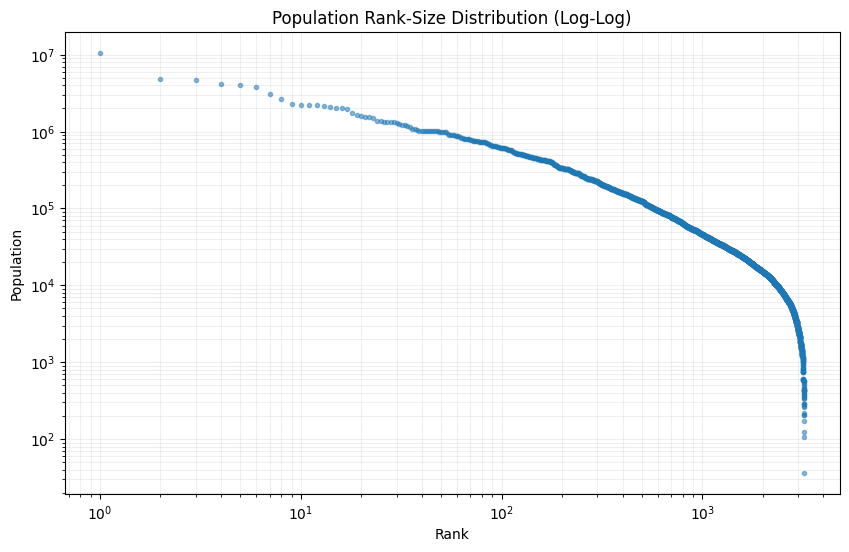

In [25]:
import matplotlib.pyplot as plt
import numpy as np

# Sort population from largest to smallest
sorted_pop = np.sort(population)[::-1]
ranks = np.arange(1, len(sorted_pop) + 1)

plt.figure(figsize=(10, 6))
plt.loglog(ranks, sorted_pop, marker='.', linestyle='none', alpha=0.5)
plt.title("Population Rank-Size Distribution (Log-Log)")
plt.xlabel("Rank")
plt.ylabel("Population")
plt.grid(True, which="both", ls="-", alpha=0.2)
plt.show()

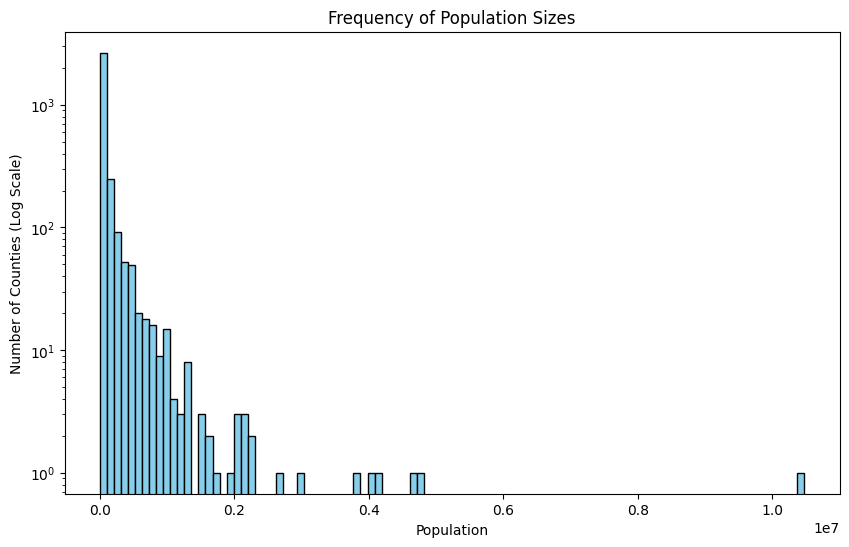

In [24]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.hist(population, bins=100, color='skyblue', edgecolor='black', log=True)
plt.title("Frequency of Population Sizes")
plt.xlabel("Population")
plt.ylabel("Number of Counties (Log Scale)")
plt.show()

In [27]:
population.sum()

312969644.5714286

In [28]:
np.savez_compressed('mobility_metadata_real.npz',
                    population=population)